<center><h2>national higer schoole of autonoumes systems</h2></center>
<center><h1>home work of linear control systems</h1></center>
<center><h2>oussama meddouri,mosif benaini</h2></center>



#

#

#

#

#

#
### Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sympy as sp
import control as ct

In [2]:
# Parameters
K = 0.5  # Nm/A
J = 0.02 # kg*m^2
b = 0.1  # Nms
L = 0.5  # H
R = 1    # Ohm

### Modle representation

In [3]:
print("--- 1. Model Representation ---")

# Transfer Function: G(s) = K / (s * ((Js + b)(Ls + R) + K^2))
# Denominator: s * (JLs^2 + (JR + bL)s + bR + K^2)
# = JLs^3 + (JR + bL)s^2 + (bR + K^2)s

num = [K]
den = [ (J+b)*(L+R), K**2]
G = ct.TransferFunction(num, den)
print(f"Transfer Function G(s):\n{G}")

--- 1. Model Representation ---
Transfer Function G(s):
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       0.5
  -------------
  0.18 s + 0.25


In [4]:
# State-Space Representation
# Let x1 = theta, x2 = theta_dot, x3 = i
# d/dt [x1; x2; x3] = [0 1 0; 0 -b/J K/J; 0 -K/L -R/L] [x1; x2; x3] + [0; 0; 1/L] V
# y = [1 0 0] [x1; x2; x3]
A = [[0, 1, 0],
     [0, -b/J, K/J],
     [0, -K/L, -R/L]]
B = [[0], [0], [1/L]]
C = [[1, 0, 0]]
D = [[0]]
sys_ss = ct.ss(A, B, C, D)
print(f"\nState-Space Representation:\nA = {A}\nB = {B}\nC = {C}\nD = {D}")


State-Space Representation:
A = [[0, 1, 0], [0, -5.0, 25.0], [0, -1.0, -2.0]]
B = [[0], [0], [2.0]]
C = [[1, 0, 0]]
D = [[0]]


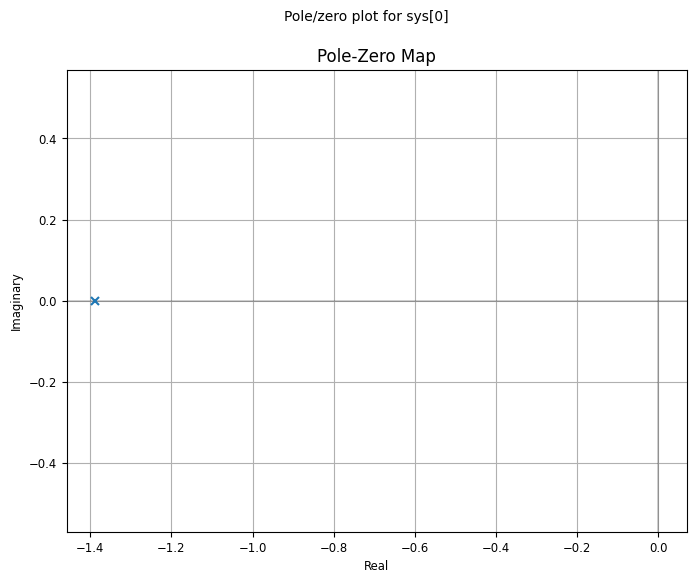

In [5]:
plt.figure(figsize=(8, 6))
ct.pole_zero_plot(G)
plt.title('Pole-Zero Map')
plt.grid(True)
plt.savefig('pole_zero_map.png')

### Time response analysis

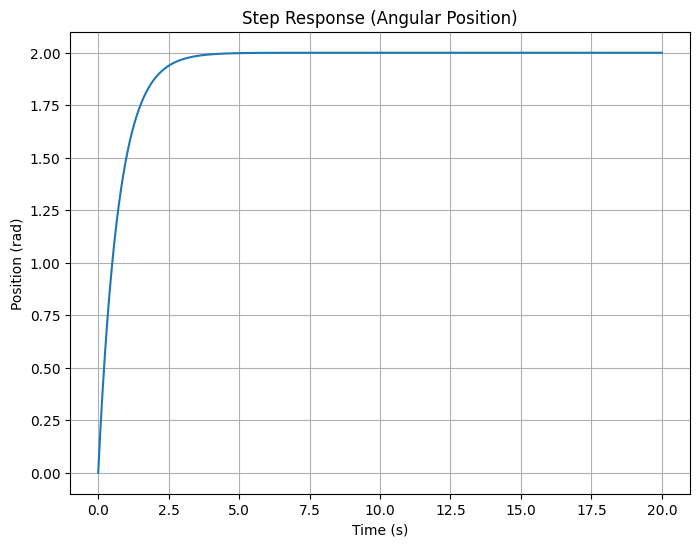

In [6]:
# Step Response
# Since it's an integrator, the position will increase indefinitely.
# Let's simulate for a finite time.
t = np.linspace(0, 20, 1000)
t, y = ct.step_response(G, T=t)
plt.figure(figsize=(8, 6))
plt.plot(t, y)
plt.title('Step Response (Angular Position)')
plt.xlabel('Time (s)')
plt.ylabel('Position (rad)')
plt.grid(True)
plt.savefig('step_response.png')


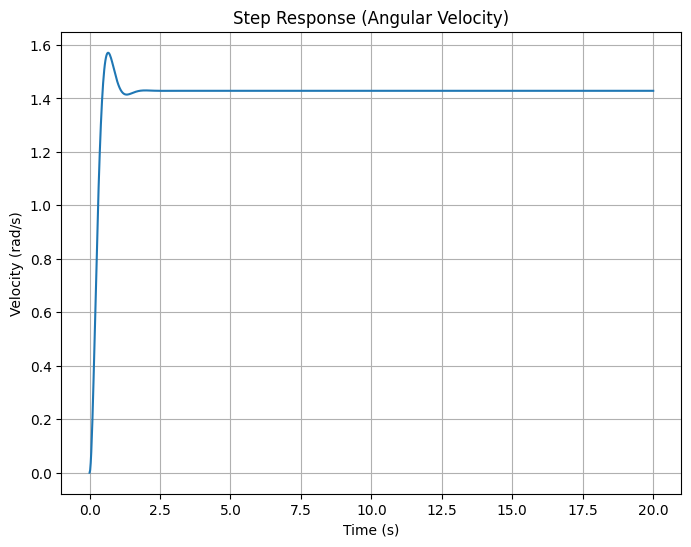

In [7]:
# Velocity Step Response (G_vel = s * G)
G_vel = ct.TransferFunction([K], [J*L, J*R + b*L, b*R + K**2])
t_vel, y_vel = ct.step_response(G_vel, T=t)
plt.figure(figsize=(8, 6))
plt.plot(t_vel, y_vel)
plt.title('Step Response (Angular Velocity)')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (rad/s)')
plt.grid(True)
plt.savefig('velocity_step_response.png')

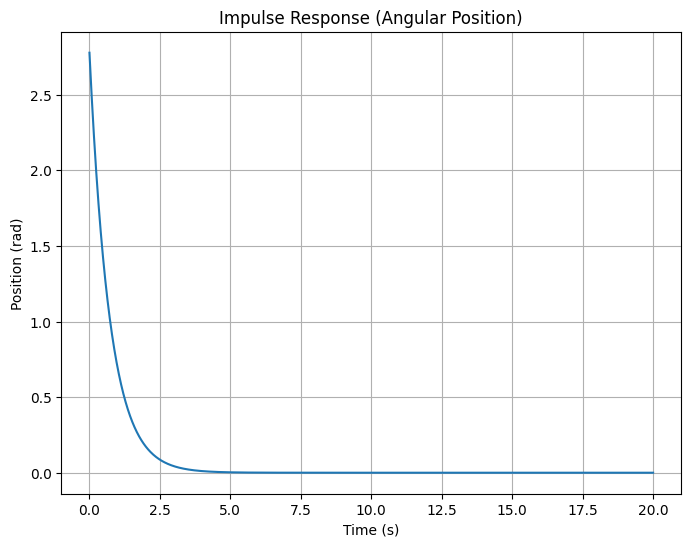

In [8]:
# Impulse Response
t_imp, y_imp = ct.impulse_response(G, T=t)
plt.figure(figsize=(8, 6))
plt.plot(t_imp, y_imp)
plt.title('Impulse Response (Angular Position)')
plt.xlabel('Time (s)')
plt.ylabel('Position (rad)')
plt.grid(True)
plt.savefig('impulse_response.png')

In [9]:
# Performance Characteristics for Velocity
info_vel = ct.step_info(G_vel)
print("Velocity Step Response Characteristics:")
print(f"Rise Time: {info_vel['RiseTime']:.4f} s")
print(f"Settling Time: {info_vel['SettlingTime']:.4f} s")
print(f"Overshoot: {info_vel['Overshoot']:.4f} %")
print(f"Steady-state value: {y_vel[-1]:.4f}")


Velocity Step Response Characteristics:
Rise Time: 0.2990 s
Settling Time: 1.0167 s
Overshoot: 9.9728 %
Steady-state value: 1.4286


 ### frequency response

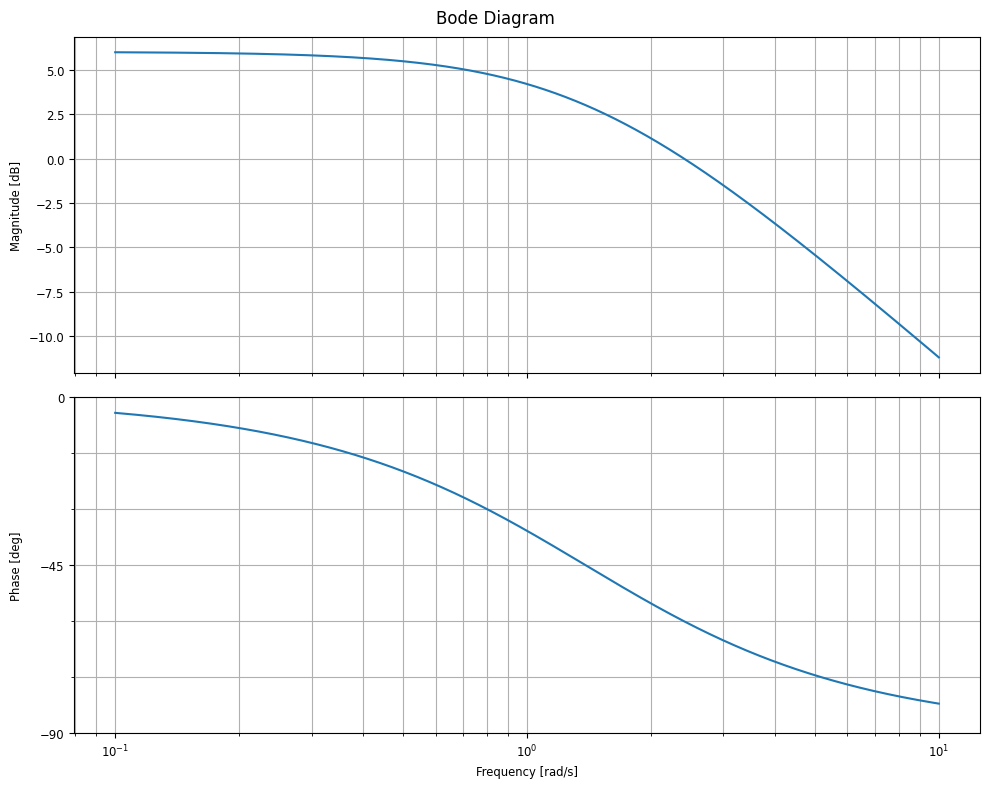

In [10]:
# Bode Plot
plt.figure(figsize=(10, 8))
ct.bode_plot(G, dB=True, Hz=False, deg=True)
plt.suptitle('Bode Diagram')
plt.savefig('bode_plot.png')


In [11]:
# Stability Margins
gm, pm, wg, wp = ct.margin(G)
print(f"Gain Margin: {gm:.4f} (at {wg:.4f} rad/s)")
print(f"Phase Margin: {pm:.4f} deg (at {wp:.4f} rad/s)")

Gain Margin: inf (at nan rad/s)
Phase Margin: 120.0000 deg (at 2.4056 rad/s)


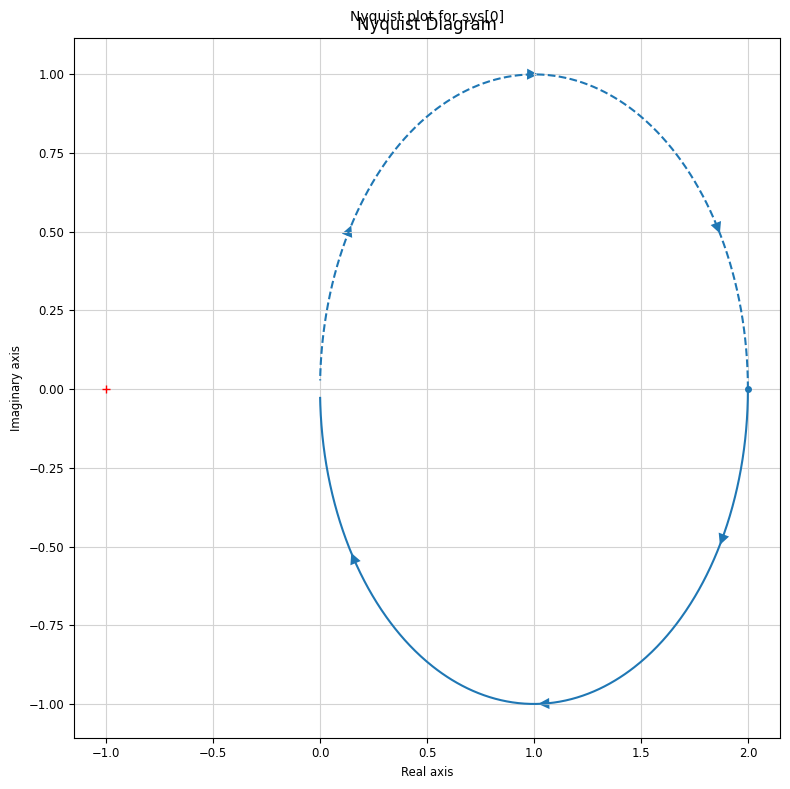

In [12]:
# Nyquist Plot
plt.figure(figsize=(8, 8))
ct.nyquist_plot(G)
plt.title('Nyquist Diagram')
plt.savefig('nyquist_plot.png')

